Hyperparameter
- ITERS = 10000
- layers = [1,128,128,128,128,8]
- BATCH = 16
- NUM_HIDDEN = 1
- MOMENTUM = 0.8
- learning_rate = 1e-6
- lr_rate = [1e-3, 1e-4, 1e-6]
- lr_boundaries = [5000, 8000]

In [1]:
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal as normal

tf.keras.backend.set_floatx('float64')
tf.compat.v1.enable_eager_execution()

In [2]:
NUM_OF_INTERNAL = 60
TOTAL_T = 60
NUM_HIDDEN = 1
MOMENTUM = 0.8
BATCH = 16
K = 5
ITERS = 10000
SEED = 12345
TEXT = "base_case" #change this one

c1 = 100 
c2 = 20
c3 = 50
c4 = 200
c5 = 1000
c6 = 300*1/2

In [3]:
birth =  0.000053
death =  0.000033 

alpha = 0.00135
sigma = 0.06352
beta1 = 0.2812 
beta2 = 0.15838 
beta3 = 0.0388 
delta1 = 0.28505
delta2 = 0.28269
delta3 = 0.14206
gamma = 0.30954
p1 = 0.01845
p2 = 0.1431
mu = 0.0042
sigma1 = 0.09275
sigma2 = 0.03887
sigma3 = 0.07517
sigma4 = 0.06302
sigma5 = 0.07878
sigma6 = 0.06123
sigma7 = 0.0611
sigma8 = 0.06199

N = 6629870
S0 = 3674149/N
V0 = 2845438/N
E0 = 67789/N
I10 = 12113/N
I20 = 498/N
I30 = 96/N
R0 = 28911/N
D0 = 876/N

init = [S0, V0, E0, I10, I20, I30, R0, D0]

In [4]:
k0 = 0.0067
k1 = -0.1676

def p1fn(alpha):
    return k0 + k1 * alpha

In [5]:
class Solver(object):

    def __init__(self, seed_var):
        self.valid_size = BATCH
        self.batch_size = BATCH
        
        self.num_iterations = ITERS
        self.print_frequency = 100
        self.lr_values = [1e-3, 1e-4, 1e-6]
        self.lr_boundaries = [5000, 8000]
        self.config = Config()

        self.model = WholeNet(seed_var)
        lr_schedule = tf.keras.optimizers.schedules.PiecewiseConstantDecay(self.lr_boundaries, self.lr_values)
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule, epsilon=1e-7)

    def train(self):
        """Training the model"""
        start_time = time.time()
        training_history = []
        control_output = [] 
        
        dW = self.config.sample(self.valid_size)
        valid_data = dW
        for step in range(self.num_iterations+1):
            if step % self.print_frequency == 0:
                cost, row_out0 = self.model(valid_data, training=True)
                elapsed_time = time.time() - start_time
                training_history.append([step, cost, elapsed_time])
                print("step: %5u, Cost: %.4e, elapsed time: %3u" % (step, cost, elapsed_time))
            if step == self.num_iterations:
                cost1, row_out1 = self.model(valid_data, training=True)
                row_output = row_out1.numpy()
                control_output.append(row_output)
            self.train_step(self.config.sample(self.batch_size))
        self.training_history = training_history
        self.control_output = control_output

    @tf.function
    def train_step(self, train_data):
        """Updating the gradients"""
        with tf.GradientTape(persistent=True) as tape:
            loss = self.model(train_data, training = True)
        grad = tape.gradient(loss, self.model.trainable_variables)
        del tape
        self.optimizer.apply_gradients(zip(grad, self.model.trainable_variables))

In [6]:
class WholeNet(tf.keras.Model):
    """Building the neural network architecture"""
    def __init__(self,seed_var):
        super(WholeNet, self).__init__()
        self.config = Config()
        self.subnet = [FNNet(seed_var) for _ in range(self.config.num_time_interval)]

    def call(self, dw, training):
        x_init = tf.ones([1, self.config.dim_x], dtype=tf.dtypes.float64) * init
        time_stamp = np.arange(0, self.config.num_time_interval) * self.config.delta_t
        all_ones = tf.ones([tf.shape(dw)[0], 1], dtype=tf.dtypes.float64)

        # initial state
        x = tf.matmul(all_ones, x_init)

        # initial cost functional
        l = 0.0 
        u_set = []
        for t in range(0, self.config.num_time_interval):
            u = self.subnet[t](x, training)
            u_set.append(tf.stack([u], axis=0))   
            l = l + self.config.f_fn(time_stamp[t], x, u) * self.config.delta_t
            x = x + self.config.b_fn(time_stamp[t], x, u) * self.config.delta_t + self.config.sigma_fn(time_stamp[t], x, u) * dw[:,:,  t]

        # control variable
        control_u = tf.stack(u_set, axis=0)
        row_ave2 = tf.reduce_mean(control_u, axis=2)
        row_out1 = tf.squeeze(row_ave2, axis=[1,2])
        #print("u timepath2", row_ave2)
        
        # terminal condition
        l = l + self.config.h_fn(self.config.total_time, x)
        cost = tf.reduce_mean(l) 
        return cost, row_out1


In [7]:
class FNNet(tf.keras.Model):
    def __init__(self, seed_var):
        super(FNNet, self).__init__()
        self.config = Config()

        tf.random.set_seed(seed_var)
        np.random.seed(seed_var)
        
        num_hiddens = [self.config.dim_x + NUM_HIDDEN, self.config.dim_x + NUM_HIDDEN, self.config.dim_x + NUM_HIDDEN]
        self.bn_layers = [
            tf.keras.layers.BatchNormalization(
                momentum=MOMENTUM,
                epsilon=1e-6,
                beta_initializer=tf.random_normal_initializer(0.0, stddev=0.1,seed=seed_var),
                gamma_initializer=tf.random_uniform_initializer(0.1, 0.5,seed=seed_var)
            )
            for _ in range(len(num_hiddens) + 2)]
        self.dense_layers = [tf.keras.layers.Dense(num_hiddens[i],
                                                   use_bias=True,
                                                   activation='tanh')
                             for i in range(len(num_hiddens))]
        
        # final output should be gradient of size dim_u
        self.dense_layers.append(tf.keras.layers.Dense(self.config.dim_u, activation='sigmoid'))

    def call(self, x, training):
        x = self.bn_layers[0](x, training)
        for i in range(len(self.dense_layers) - 1):
            x = self.dense_layers[i](x)
            x = self.bn_layers[i+1](x, training)
            x = tf.nn.tanh(x)
        x = self.dense_layers[-1](x)
        x = self.bn_layers[-1](x, training)
        return tf.nn.tanh(x) * 0.012 + 0.016

In [8]:
class Config(object):
    """function config"""
    def __init__(self):
        super(Config, self).__init__()
        self.dim_x = 8
        self.dim_u = 1
        self.num_time_interval = NUM_OF_INTERNAL
        self.total_time = TOTAL_T
        self.delta_t = (self.total_time + 0.0) / self.num_time_interval
        self.sqrth = np.sqrt(self.delta_t)
        self.t_stamp = np.arange(0, self.num_time_interval) * self.delta_t

    # sample function
    def sample(self, num_sample):
        dw_sample = normal.rvs(size=[num_sample, self.dim_x, self.num_time_interval]) * self.sqrth
        return dw_sample

    # cost functional integral item
    def f_fn(self, t, x, u):
        tensors = []
        for i in range(BATCH):
            S = x[i][0]
            V = x[i][1]
            E = x[i][2]
            I1 = x[i][3]
            I2 = x[i][4]
            I3 = x[i][5]
            R = x[i][6]
            D = x[i][7]
            alpha = u[i][0]  
            cost = (c1 * alpha ** 2 + c2 * E + (c3*I1 + c4*I2 + c5*I3) + c6 * (tf.maximum(tf.cast(0, tf.float64), 1-(S+V+R)))) 
            combined_cost = tf.stack([cost], axis=0)
            tensors.append(combined_cost)
            combined_tensor = tf.stack(tensors, axis=0)
        return tf.reduce_sum(combined_tensor, 1, keepdims=True)

    # cost fuctional terminal function
    def h_fn(self, t, x):
        return 0

    def b_fn(self, t, x, u):
        tensors = []
        for i in range(BATCH):
            S = x[i][0]
            V = x[i][1]
            E = x[i][2]
            I1 = x[i][3]
            I2 = x[i][4]
            I3 = x[i][5]
            R = x[i][6]
            D = x[i][7]
            alpha = u[i][0]
            dS = birth + (- ( beta1 * I1 + beta2 * I2 + beta3 * I3) * S  - alpha * S) - death*S
            dV = (alpha * S - sigma * (beta1 * I1 + beta2 * I2 + beta3 * I3) * V) - death*V
            dE = ((beta1 * I1 + beta2 * I2 + beta3 * I3) * S  + sigma * (beta1 * I1 + beta2 * I2 + beta3 * I3) * V - gamma * E) - death*E
            dI1 = (gamma * E - (delta1 + p1fn(alpha)) * I1) - death*I1
            dI2 = (p1fn(alpha) * I1 - (delta2 + p2) * I2) - death*I2
            dI3 = (p2 * I2 - (delta3 + mu) * I3) - death*I3
            dR = (delta1 * I1+ delta2 * I2 + delta3 * I3) - death*R
            dD = (mu * I3) 
            combined_ten = tf.stack([dS, dV,dE,dI1,dI2,dI3,dR,dD], axis=0)
            tensors.append(combined_ten)
            combined_tensor = tf.stack(tensors, axis=0)
        return combined_tensor

    def sigma_fn(self, t, x, u):
        #return x
        tensors = []
        for i in range(BATCH):
            S = x[i][0]
            V = x[i][1]
            E = x[i][2]
            I1 = x[i][3]
            I2 = x[i][4]
            I3 = x[i][5]
            R = x[i][6]
            D = x[i][7]
            sig_S = sigma1*S
            sig_V = sigma2*V
            sig_E = sigma3*E
            sig_I1 = sigma4*I1
            sig_I2 = sigma5*I2
            sig_I3 = sigma6*I3
            sig_R = sigma7*R
            sig_D = sigma8*D
            combined_sig = tf.stack([sig_S, sig_V,sig_E,sig_I1,sig_I2,sig_I3,sig_R,sig_D], axis=0)
            tensors.append(combined_sig)
            combined_tensor = tf.stack(tensors, axis=0)
        return combined_tensor

In [9]:
output_table = np.zeros((int(round(ITERS) / 100) + 1, 2 + int(round(K))))
control_outs_table = np.zeros((int(round(K)), TOTAL_T))


def main():
    solver = Solver(seed_var=SEED)
    print('Training time %3u:' % (1))
    solver.train()
    data = np.array(solver.training_history)
    control_output_data = np.array(solver.control_output)
    k = K
    
    output = np.zeros((len(data[:, 0]), 2 + k))
    output[:, 0] = data[:, 0]
    output[:, 1] = data[:, 2]
    output[:, 2] = data[:, 1]
    output_table[:, 0] = data[:, 0]
    output_table[:, 1] = data[:, 2]
    output_table[:, 2] = data[:, 1]

    
    control_outs = np.zeros((k, len(control_output_data[0])))
    control_outs[0] = control_output_data[0]

    
    for i in range(k - 1):
        print('Training time %3u:' % (i + 2))
        solver = Solver(seed_var=12345+1+i)  
        solver.train()
        data = np.array(solver.training_history)
        control_output_data = np.array(solver.control_output)
        output[:, 3 + i] = data[:, 1]
        output_table[:, 3 + i] = data[:, 1]
        control_outs[1+i] = control_output_data[0]
        control_outs_table[1+i] = control_output_data[0]

    a = ['%d', '%.5e']
    for _ in range(k):
        a.append('%.5e')
    
    con_format = ['%.5e']
    for _ in range(len(control_output_data[0])-1):
        con_format.append('%.5e')
        
    np.savetxt('./Sto_control_Opt_Vacc_'+str(TEXT)+'.csv', control_outs, fmt=con_format, delimiter=',')
    np.savetxt('./Sto_control_Loss_'+str(TEXT)+'.csv', output, fmt=a, delimiter=',')
    print('Solving is done!')

if __name__ == '__main__':
    main()


2025-12-08 21:05:11.120668: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2025-12-08 21:05:11.120933: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.2
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Training time   1:
step:     0, Cost: 7.8081e+02, elapsed time:   5


2025-12-08 21:12:50.150466: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:116] None of the MLIR optimization passes are enabled (registered 2)


step:   100, Cost: 7.7581e+02, elapsed time: 750
step:   200, Cost: 7.7420e+02, elapsed time: 774
step:   300, Cost: 7.7230e+02, elapsed time: 798
step:   400, Cost: 7.6913e+02, elapsed time: 820
step:   500, Cost: 7.6686e+02, elapsed time: 843
step:   600, Cost: 7.6566e+02, elapsed time: 866
step:   700, Cost: 7.6560e+02, elapsed time: 890
step:   800, Cost: 7.6512e+02, elapsed time: 913
step:   900, Cost: 7.6538e+02, elapsed time: 936
step:  1000, Cost: 7.6482e+02, elapsed time: 959
step:  1100, Cost: 7.6507e+02, elapsed time: 981
step:  1200, Cost: 7.6306e+02, elapsed time: 1004
step:  1300, Cost: 7.6280e+02, elapsed time: 1027
step:  1400, Cost: 7.6394e+02, elapsed time: 1050
step:  1500, Cost: 7.6316e+02, elapsed time: 1073
step:  1600, Cost: 7.6471e+02, elapsed time: 1096
step:  1700, Cost: 7.6356e+02, elapsed time: 1118
step:  1800, Cost: 7.6456e+02, elapsed time: 1141
step:  1900, Cost: 7.6428e+02, elapsed time: 1165
step:  2000, Cost: 7.6532e+02, elapsed time: 1189
step:  2100

In [10]:
loss_val = output_table[:, 2]
for i in range(K-1):
    loss_val = loss_val + output_table[:, i+3]
average_cost = loss_val/K
print(average_cost)

[680.01731696 675.86559741 673.14629642 668.40740132 664.6876719
 662.76350929 660.90776154 659.60447995 658.67875219 657.80444723
 655.73775938 654.98273199 653.68386798 653.64712043 652.16633002
 651.68613929 651.47833787 651.19273178 650.21107041 649.76695074
 650.05357806 649.42666893 649.23858507 649.31034911 649.05539891
 649.35970268 648.30755303 648.27321149 648.22551772 648.22320769
 648.16387859 647.68147688 647.82882865 648.09422847 648.14737559
 647.33341677 647.51922867 647.6491273  647.56456433 647.12991977
 647.06403384 647.11835609 647.15001031 647.09322969 647.53189531
 647.46663714 646.9538193  646.91875356 647.10700044 647.26055158
 647.16086431 647.13685736 647.1049548  647.09432359 647.08439045
 647.06538392 647.0520926  647.03014914 647.05559482 647.05283719
 647.04225702 647.03427936 646.99462761 646.96142859 646.95188209
 646.94430746 646.93005107 646.91098173 646.90902992 646.90996007
 646.87970833 646.88828903 646.85901884 646.8367314  646.80856389
 646.796866

In [11]:
print(output_table)
#cost1 = output_table[:, 2]
#cost2 = output_table[:, 3]
#cost3 = output_table[:, 4]

# Compute averages
#average_cost = (cost1 + cost2+ cost3) / 3
#print(average_cost)

[[0.00000000e+00 5.74291992e+00 7.80810706e+02 5.96265863e+02
  5.85605720e+02 6.39337022e+02 7.98067274e+02]
 [1.00000000e+02 7.50178687e+02 7.75812808e+02 5.91311959e+02
  5.77414155e+02 6.42841669e+02 7.91947397e+02]
 [2.00000000e+02 7.74520129e+02 7.74200146e+02 5.87391241e+02
  5.72555173e+02 6.42362742e+02 7.89222180e+02]
 [3.00000000e+02 7.98188657e+02 7.72301863e+02 5.82611536e+02
  5.64813572e+02 6.35925484e+02 7.86384552e+02]
 [4.00000000e+02 8.20940302e+02 7.69134407e+02 5.77935670e+02
  5.62575496e+02 6.31360826e+02 7.82431960e+02]
 [5.00000000e+02 8.43985961e+02 7.66858345e+02 5.74077962e+02
  5.64712625e+02 6.28984542e+02 7.79184073e+02]
 [6.00000000e+02 8.66921266e+02 7.65662411e+02 5.71783556e+02
  5.61048446e+02 6.30921769e+02 7.75122626e+02]
 [7.00000000e+02 8.90312587e+02 7.65601319e+02 5.69376687e+02
  5.62095274e+02 6.28497022e+02 7.72452097e+02]
 [8.00000000e+02 9.13308883e+02 7.65115913e+02 5.67134708e+02
  5.63791401e+02 6.27088269e+02 7.70263470e+02]
 [9.000000

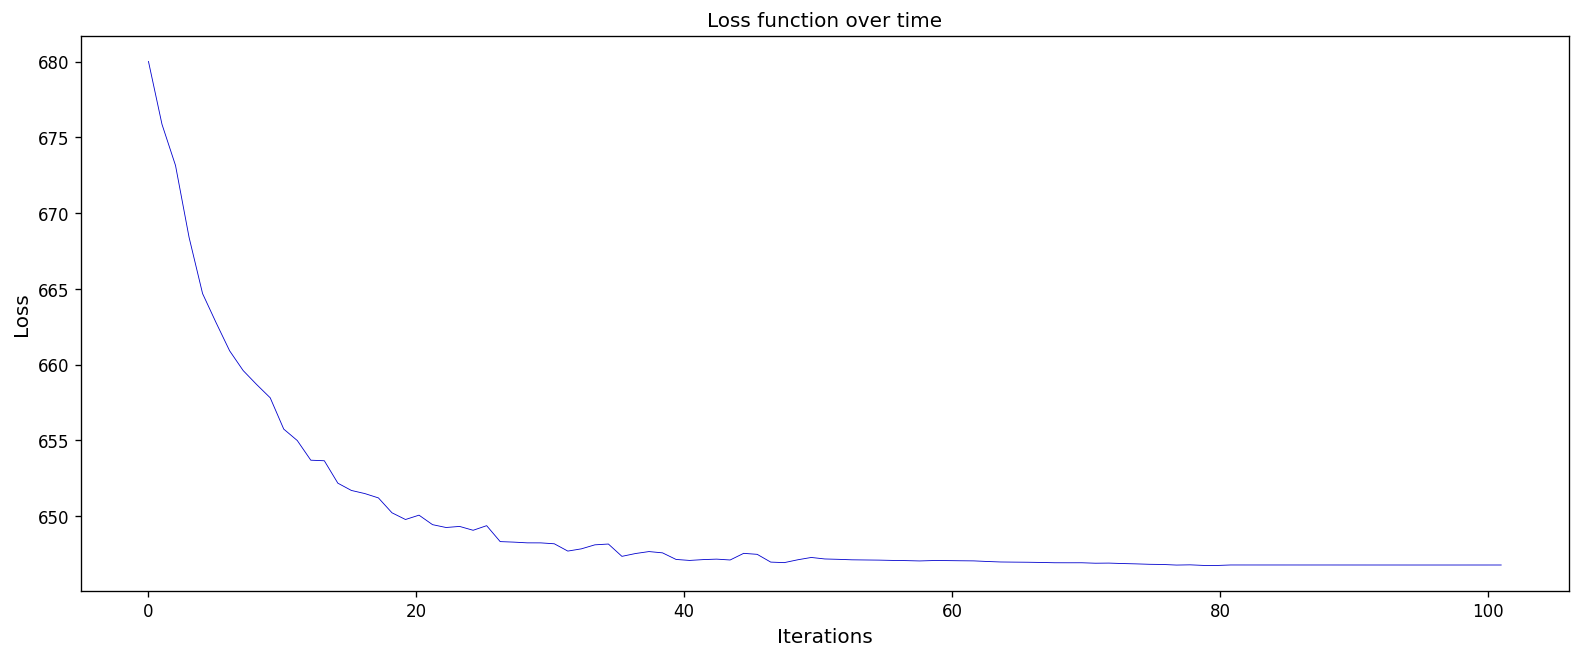

In [12]:
t = np.linspace(0, len(average_cost), len(average_cost))
fig, ax0 = plt.subplots(1, 1, figsize =(16,6), dpi = 120, sharey = True)
ax0.plot(t, average_cost, lw = 0.5, color = 'mediumblue', label = 'average_cost')
ax0.set_xlabel('Iterations', fontsize = 12)
ax0.set_ylabel('Loss', fontsize = 12)
ax0.set_title('Loss function over time', fontsize = 12)
plt.savefig('Loss_'+str(TEXT)+'.png')

[0.02779241 0.02779376 0.0277793  0.02776553 0.0277453  0.02771912
 0.0276928  0.02765907 0.0276211  0.02759403 0.02758931 0.02748176
 0.027356   0.02725343 0.02700802 0.02682949 0.02669729 0.02602627
 0.02591093 0.02538768 0.02543292 0.02521798 0.02483283 0.02442331
 0.02411679 0.02359027 0.02261898 0.02239345 0.02142741 0.02113015
 0.02051084 0.01976012 0.01890783 0.01826459 0.01757061 0.01685877
 0.01581951 0.01453682 0.01411042 0.01372562 0.0128701  0.01200073
 0.01170764 0.01122434 0.01048237 0.00977038 0.00905005 0.00841241
 0.00729049 0.00631609 0.00578246 0.00529635 0.00481603 0.00456111
 0.00438921 0.00430517 0.00426843 0.00425404 0.00425233 0.00424854]


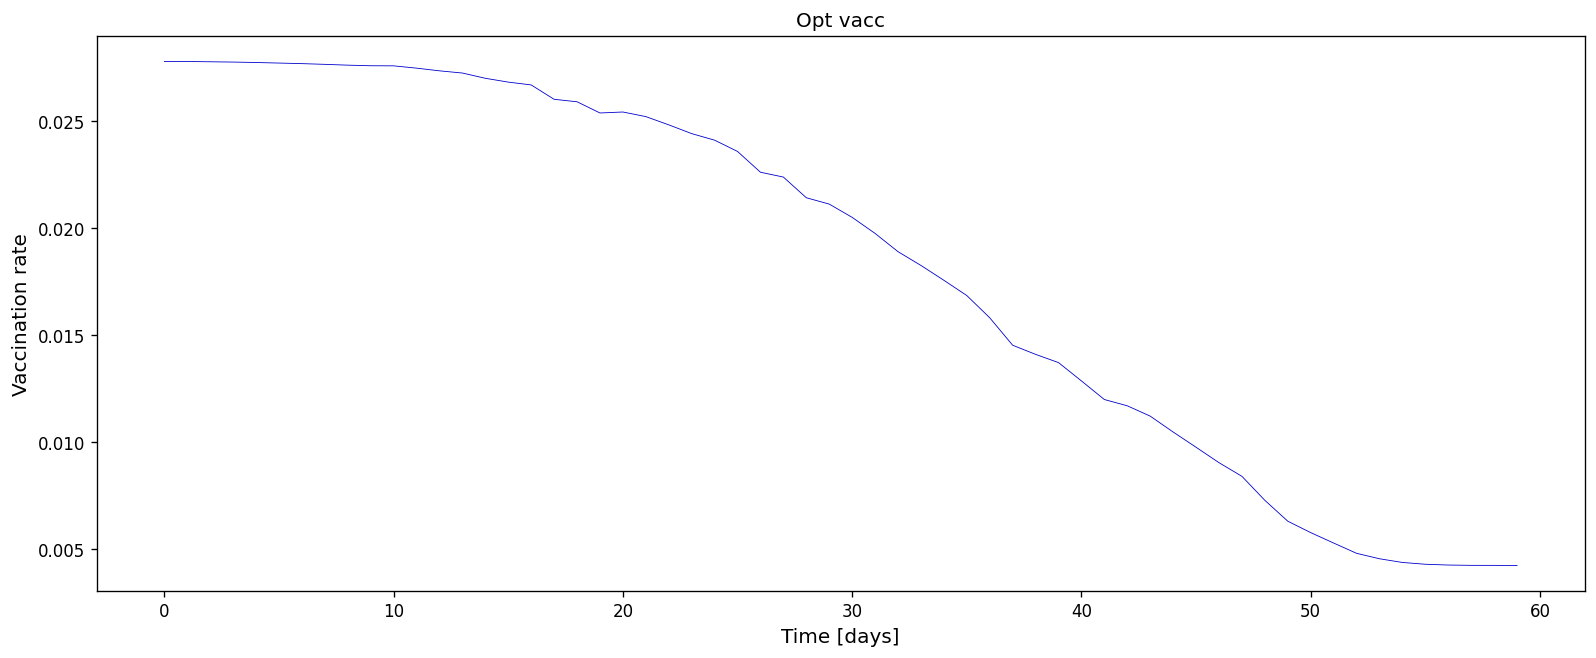

In [13]:
print(control_outs_table[1:2,:].flatten())
t = np.linspace(0, len(control_outs_table[1:2,:].flatten()),len(control_outs_table[1:2,:].flatten()))
fig, ax0 = plt.subplots(1, 1, figsize =(16,6), dpi = 120, sharey = True)
ax0.plot(control_outs_table[1:2,:].flatten(), lw = 0.5, color = 'mediumblue', label = 'average_cost')
ax0.set_xlabel('Time [days]', fontsize = 12)
ax0.set_ylabel('Vaccination rate', fontsize = 12)
ax0.set_title('Opt vacc', fontsize = 12)
plt.savefig('Opt vacc_'+str(TEXT)+'.png')